In [6]:
from deep_learning.NN_datasets import NoNoiseDataset, custom_dataloader
from deep_learning.NN_models import ResNet50
from noise_applicator.noisers.base_noiser import EuclidNoiserInterfPSF

from torch.profiler import (
    profile,
    record_function,
    ProfilerActivity,
    schedule,
    tensorboard_trace_handler,
)
import torch
from torch.nn import CrossEntropyLoss

# — your existing dataset & loader, unchanged —
my_dataset = NoNoiseDataset(
    'testin',
    grid_width_arcsec=8.0,
    grid_pixel_side=80,
    broadcasting=True,
    upscaling=5
)
loader = custom_dataloader(my_dataset, batch_size=8)
noiser = EuclidNoiserInterfPSF()
# — model, loss, optimizer (unchanged) —
device   = torch.device("cuda")
model    = ResNet50().to(device)
optimizer= torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn  = CrossEntropyLoss()

# — profiled loop, nothing else changes —
def run_batch(prof):
    it = iter(loader)
    for step in range(10):                # only measure 10 iterations
        # make sure all prior GPU work is done
        torch.cuda.synchronize()

        # === DataGen region ===
        with record_function("DataGen_on_CUDA"):
            imgs, target = next(it)       # <-- your on‐GPU batch generation
            torch.cuda.synchronize()

            imgs = noiser(imgs)
        # isolate it fully
        torch.cuda.synchronize()

        # zero grads before backward
        optimizer.zero_grad()

        # === Forward+Backward region ===
        with record_function("Fwd+Bwd"):
            out = model(imgs)
            loss = loss_fn(out, target)
            loss.backward()
            optimizer.step()

        prof.step()                       # advance profiler to next step

# — simple schedule: skip 1 warmup, record 5 iters, then stop —
sched = schedule(wait=1, warmup=1, active=5, repeat=1)

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    schedule=sched,
    record_shapes=True,
    with_stack=True,
    on_trace_ready=tensorboard_trace_handler("./log/"),
) as prof:
    run_batch(prof)

# then launch:
# tensorboard --logdir=./log
# you’ll see two bars per iteration: “DataGen_on_CUDA” vs “Fwd+Bwd”


Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
tensor(100)
The PthPSF is loaded as it is. All the physical considerations must be done building it.


Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
tensor(100)
Panel saved to: thesis_image_panel_8x2.png


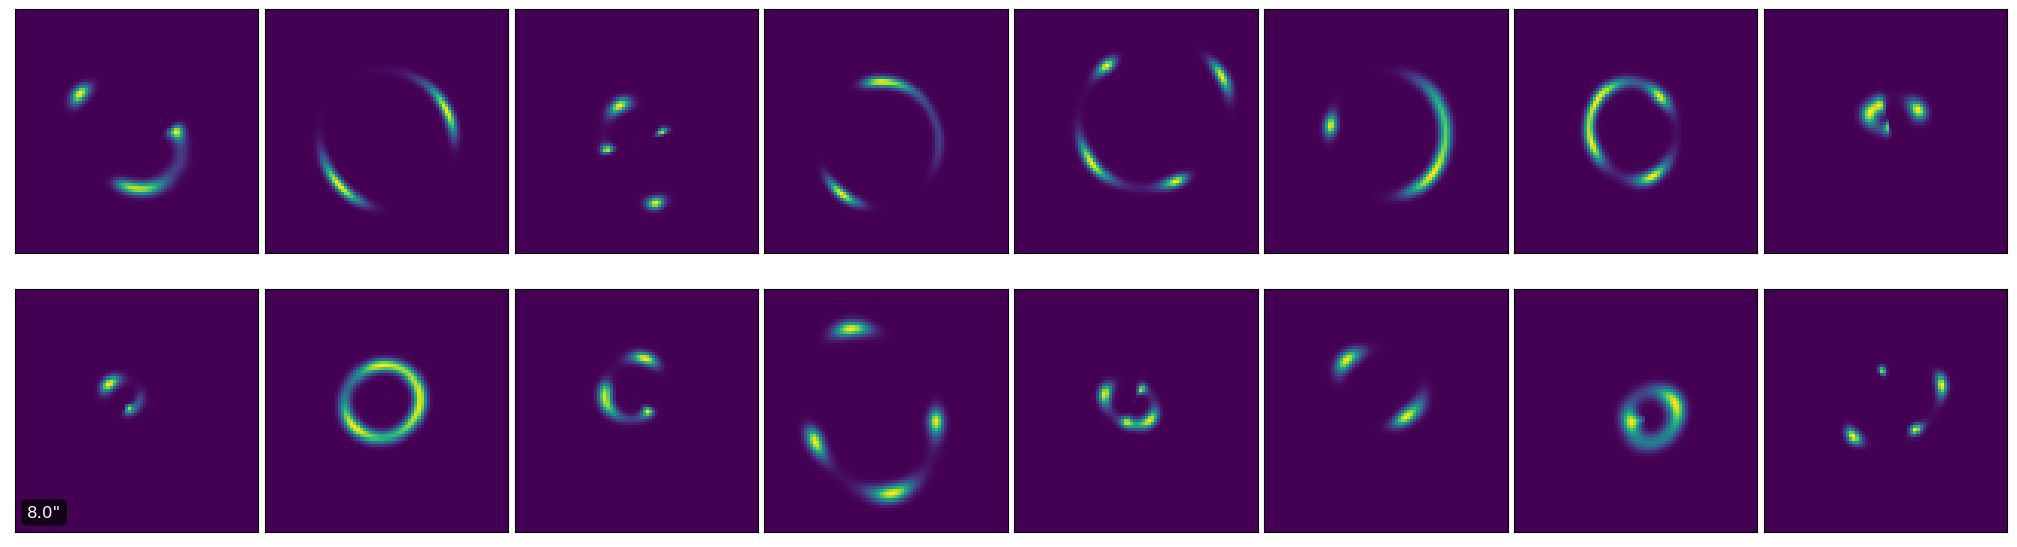

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

my_dataset = NoNoiseDataset(
    'testin',
    grid_width_arcsec=8.0,
    grid_pixel_side=80,
    broadcasting=True,
    upscaling=10
)
loader = custom_dataloader(my_dataset, batch_size=16)


import matplotlib.pyplot as plt
import numpy as np
import torch

def create_image_panel(loader, n_images=16, figsize=(20, 6), 
                      grid_width_arcsec=8.0, save_path=None, dpi=300,
                      rows=2, cols=8):
    """
    Create a panel of N images from your dataloader for thesis presentation.
    Default setup for 8x2 layout (16 images total).
    
    Args:
        loader: Your custom dataloader
        n_images: Number of images to display (default 16 for 8x2 grid)
        figsize: Figure size in inches (default optimized for 8x2)
        grid_width_arcsec: Width of each image in arcseconds
        save_path: Path to save the figure (optional)
        dpi: Resolution for saving
        rows: Number of rows (default 2)
        cols: Number of columns (default 8)
    """
    
    # Use specified grid dimensions
    # Override n_images if it doesn't match grid
    if n_images != rows * cols:
        n_images = rows * cols
        print(f"Adjusted n_images to {n_images} to match {rows}x{cols} grid")
    
    # Get batch from dataloader
    batch_iter = iter(loader)
    batch = next(batch_iter)
    
    # Assuming batch is (images, labels) or just images
    if isinstance(batch, (list, tuple)):
        images = batch[0]  # First element is typically images
    else:
        images = batch
    
    # Convert to numpy if tensor
    if torch.is_tensor(images):
        images = images.cpu().numpy()
    
    # Take first n_images
    images = images[:n_images]
    
    # Create figure and subplots
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    # Handle single subplot case
    if n_images == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    # Plot images
    for i in range(n_images):
        ax = axes[i]
        
        # Handle different image formats (grayscale vs RGB)
        img = images[i]
        if len(img.shape) == 3:
            if img.shape[0] in [1, 3]:  # Channel first format
                img = np.transpose(img, (1, 2, 0))
            if img.shape[2] == 1:  # Grayscale with channel dimension
                img = img.squeeze(-1)
        
        # Display image
        im = ax.imshow(img, cmap='viridis' if len(img.shape) == 2 else None,
                      origin='lower', interpolation='nearest')
        
        # Remove ticks
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add scale bar annotation to bottom left image only (last row, first column)
        if i == (rows - 1) * cols:  # Bottom left corner (first image of last row)
            ax.text(0.05, 0.05, f'{grid_width_arcsec}"', 
                   transform=ax.transAxes, 
                   fontsize=12, color='white', 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7),
                   verticalalignment='bottom')
    
    # Hide unused subplots
    for i in range(n_images, len(axes)):
        axes[i].set_visible(False)
    
    # Adjust layout
    plt.tight_layout(pad=0.1)
    
    # Add overall title if desired
    # fig.suptitle('Sample Images from Dataset', fontsize=16, y=0.98)
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        print(f"Panel saved to: {save_path}")
    
    plt.show()
    return fig

# Example usage:
# Create an 8x2 panel (16 images) - default
fig = create_image_panel(loader, 
                        grid_width_arcsec=8.0,
                        save_path='thesis_image_panel_8x2.png')

# For other 8x2 variations:
# 8x2 with different aspect ratio
# fig = create_image_panel(loader, figsize=(24, 6))

# 8x2 with fewer images (will fill from top-left)
# fig = create_image_panel(loader, n_images=12, rows=2, cols=8)

# Different layouts if needed:
# 4x4 panel (16 images) 
# fig = create_image_panel(loader, rows=4, cols=4, figsize=(16, 16))

# 2x8 panel (16 images, wide format)
# fig = create_image_panel(loader, rows=8, cols=2, figsize=(6, 20))